<div class='alert alert-block alert-info"'>
<h1> Application to plant senescence genetic marker
identification :</h1>

<h4> Estimation and variable selection in an Mixed-effect models </h4>

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

sdgplt.FIGSIZE = 10

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


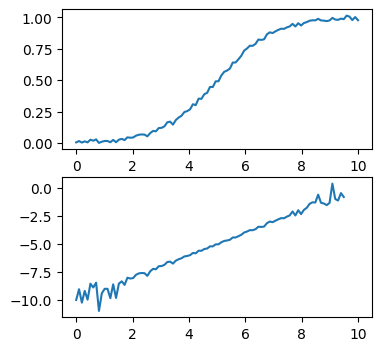

In [2]:
t = jnp.linspace(0, 10, num=100)
# y = 2 + t*4 + 0.1*jrd.normal(jrd.PRNGKey(0), shape = t.shape)


def m(x):
    return 1 / (1 + jnp.exp(-(x - 5)))


def g(y):
    return -jnp.log(1 / y - 1) - 5


y = m(t) + 0.01 * jrd.normal(jrd.PRNGKey(0), shape=t.shape)
y = jnp.where(y < 0, m(0), y)

sdgplt.FIGSIZE = 4
fig = sdgplt.figure()
ax = fig.add_subplot(2, 1, 1)
ax.plot(t, y)
ax = fig.add_subplot(2, 1, 2)
ax.plot(t, g(y))

### Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [3]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
    cov_simulation,
)


class HDLogisticMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["ksi"],
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)

        self.init()

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu=pc.RealPositive(scale=2000),
            ),
            psi1=pc.RealPositive(scale=100),
            psi2=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixSymPosDef(dim=1, scale=(100)),
            var_residual=pc.RealPositive(scale=100),
            beta=pc.Real(scale=10, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        ksi: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        psi1 = supremum
        ksi = midpoint
        psi2 = growth rate
        """
        phi = cov @ params.beta + ksi

        out = params.psi1 / (1 + jnp.exp(-(times - phi[:, None]) / params.psi2))
        assert out.shape == times.shape
        return out

    # ============================================================== #
    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=3)

        # === nlmem_simulation() === #
        time = 150 + jnp.arange(0, self.J - 1) * (3000 - 150) / (self.J - 1)
        time = jnp.repeat(time[None, :], self.N, axis=0)

        cov = cov_simulation(prngkey_cov, cov_min=-1, cov_max=1, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

### Data Generation
Then we can generate a data set with $N=1000$ individuals and $J=20$ observation time per individuals

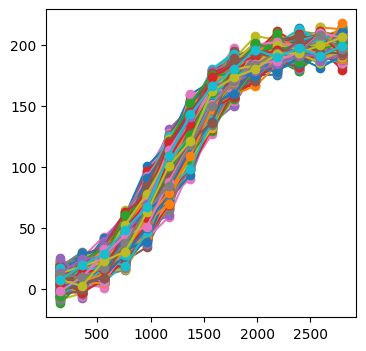

In [4]:
myModel = HDLogisticMixedEffectsModel(N=1000, J=15, P=5)

p_star = myModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate([jnp.array([100, 50, 20]), jnp.zeros(shape=(myModel.P - 3,))]),
)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

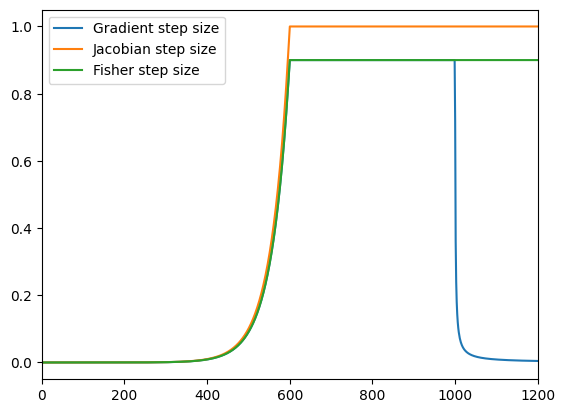

In [5]:
from sdg4varselect.outputs import GDResults, MultiRunRes
from sdg4varselect.algo import SPGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 1200)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [6]:
def one_estim(prngkey, model, data, lbd=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SPGD_FIM(prngkey_estim, 10000, algo_settings, lbd=lbd, alpha=1.0)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"ksi": 20})

    algo.latent_variables["ksi"].adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    # for var in algo.latent_variables.values():
    #     sdgplt.plot(var)

    return res  # , algo

Now we perform severals estimations : 

In [7]:
multi_estim = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(2)]
)

We can obtain the calculation time

In [8]:
print(multi_estim.chrono)

0:00:04.498825


And plot the results

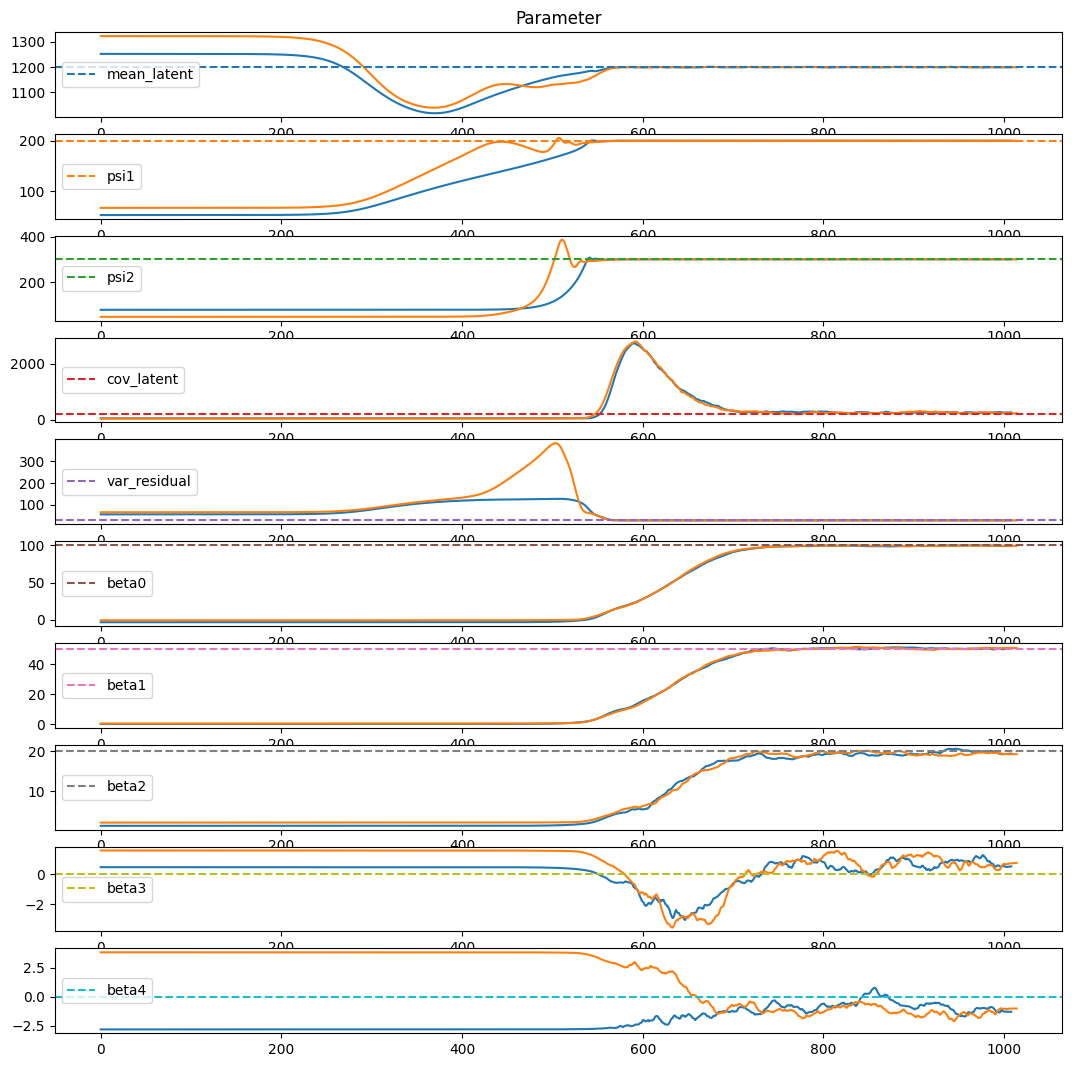

In [9]:
# === PLOT === #
sdgplt.FIGSIZE = 13

fig, axs = sdgplt.plot(
    multi_estim,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
)

In [10]:
import pandas as pd

rmse = jnp.sqrt(
    ((jnp.array(multi_estim.last_theta) - myModel.hstack_params(p_star)) ** 2).mean(
        axis=0
    )
)
pd.DataFrame(
    jnp.array(
        [
            rmse,
            jnp.array(multi_estim.last_theta).mean(axis=0),
            myModel.hstack_params(p_star),
            rmse / jnp.abs(myModel.hstack_params(p_star)),
        ]
    ).T,
    columns=["rmse", "value", "real value", "rrmse"],
    index=myModel.params_names,
).style.format(
    {
        "rmse": "{:.4f}".format,
        "value": "{:.4f}".format,
        "real value": "{:.3f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,rmse,value,real value,rrmse
mean_latent,0.8856,1199.1274,1200.000,0.1%
psi1,0.0195,199.9857,200.000,0.0%
psi2,0.5008,300.4994,300.000,0.2%
cov_latent,50.0259,247.7145,200.000,25.0%
var_residual,0.6830,29.3181,30.000,2.3%
beta0,0.8823,99.1238,100.000,0.9%
beta1,0.7377,50.6657,50.000,1.5%
beta2,0.6139,19.3898,20.000,3.1%
beta3,0.6301,0.6191,0.000,inf%
beta4,1.1481,-1.1397,0.000,inf%


In [11]:
multi_estim.likelihood.var()

Array(0.20231575, dtype=float64)

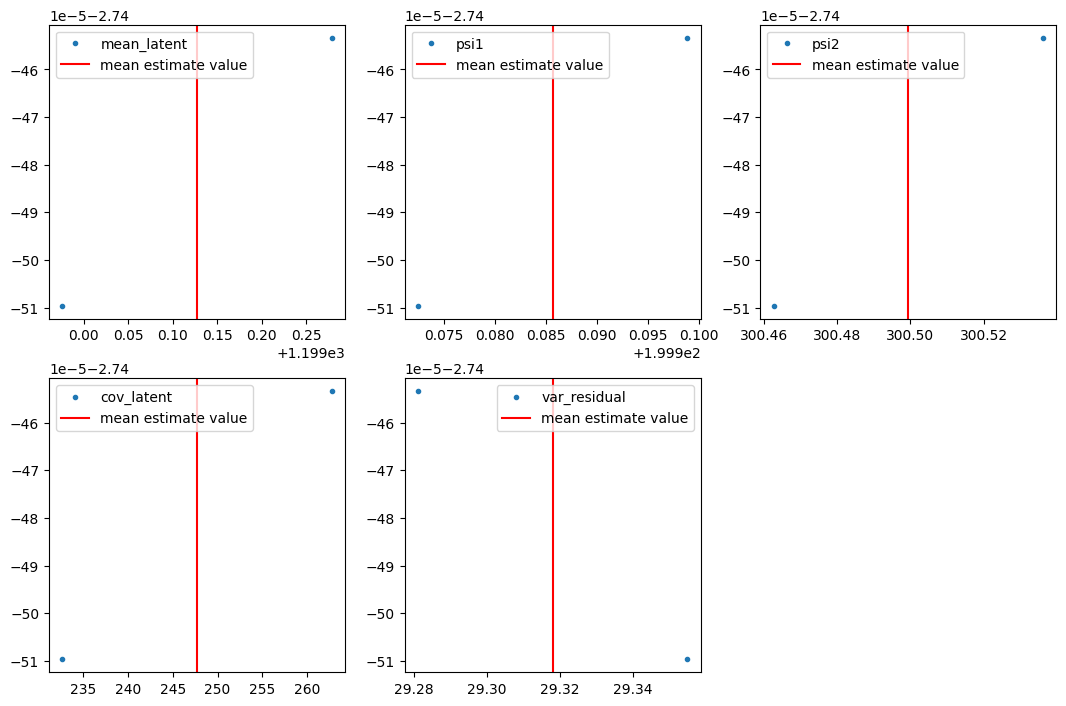

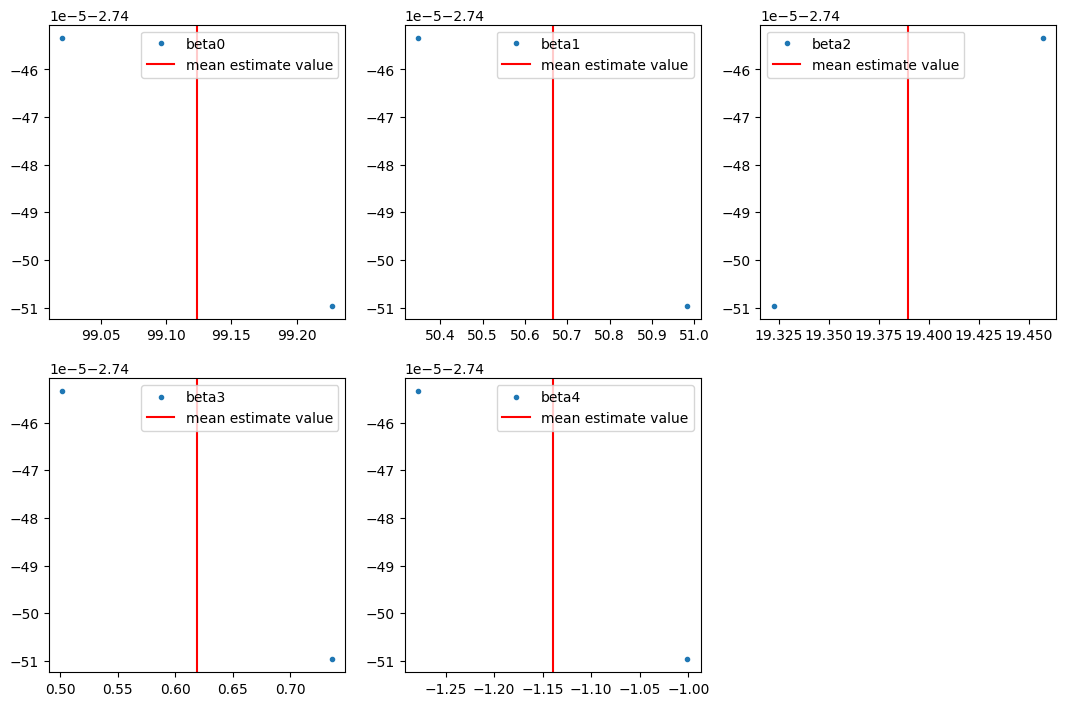

In [12]:
fig = sdgplt.figure()
id = [1, 2, 3, 4, 5, 6, 7, 8, 9]
params_names = myModel.params_names

multi_theta = jnp.array(multi_estim.last_theta)
likelihood = multi_estim.likelihood / (myModel.N * (myModel.J + 1))

pstar = myModel.hstack_params(p_star)
for i in range(5):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.plot(
        multi_theta[:, i],
        likelihood,
        ".",
        label=params_names[i],
    )
    # ax.axvline(x=pstar[i], color="k", label="true value")
    ax.axvline(
        x=multi_theta[:, i].mean(),
        color="r",
        label="mean estimate value",
    )
    ax.legend()

fig = sdgplt.figure()
for i in range(5, 10):
    ax = fig.add_subplot(3, 3, 1 + i - 5)
    ax.plot(
        multi_theta[:, i],
        likelihood,
        ".",
        label=params_names[i],
    )
    # ax.axvline(x=pstar[i], color="k", label="true value")
    ax.axvline(
        x=multi_theta[:, i].mean(),
        color="r",
        label="mean estimate value",
    )
    ax.legend()

High Dimension

In [13]:
from sdg4varselect import regularization_path, lasso_into_estim
from sdg4varselect.outputs import RegularizationPathRes, MultiRunRes


def estim_with_flag(model, **kwargs) -> tuple[MultiRunRes, bool]:
    """must return the estimation results and
    a flag which indicates if the regularization path is finished"""
    res_estim = lasso_into_estim(one_estim, model=model, **kwargs)
    dim_ld = model.DIM_LD
    flag = (res_estim[-1].last_theta[dim_ld:] != 0).sum() == 0

    return res_estim, flag


def one_result(prngkey, model, data, lbd_set, save_all=True):

    list_sdg_results, bic = regularization_path(
        estim_fct_with_flag=estim_with_flag,
        prngkey=prngkey,
        lbd_set=lbd_set,
        dim_ld=model.DIM_LD,
        N=model.N * (1 + model.J),
        verbatim=True,  # __name__ == "__main__",
        # additional parameter
        model=model,
        data=data,
        save_all=save_all,
    )

    argmin_bic = bic[-1].argmin()

    return RegularizationPathRes(
        multi_run=list_sdg_results,
        argmin_bic=argmin_bic,
        bic=bic,
        lbd_set=lbd_set,
    )

One function for multiple estimation

In [14]:
from datetime import datetime

from sdg4varselect.exceptions import sdg4vsNanError
from sdg4varselect.outputs import MultiRegRes
from sdg4varselect.miscellaneous import step_message


# ====================================================== #
def multi_run(prngkey, lbd_set, params_star, model, nrun, save_all=True):
    chrono_start = datetime.now()
    print(f'start at {chrono_start.strftime("%d/%m/%Y %H:%M:%S")}')

    prngkey_list = jrd.split(prngkey, num=nrun)

    estim_res = []
    censoring_rate = []
    end = "\r" if __name__ == "__main__" else "\n"
    for k in range(nrun):
        print("run", step_message(k, nrun), end=end)
        data, _ = model.sample(params_star, prngkey_list[k])

        try:
            estim_res.append(
                one_result(
                    prngkey_list[k],
                    model,
                    data=data,
                    lbd_set=lbd_set,
                    save_all=save_all,
                ),
            )

        except sdg4vsNanError as err:
            print(f"{err} :  estimation cancelled !")

    return MultiRegRes(estim_res)

In [15]:
myHDModel = HDLogisticMixedEffectsModel(N=1000, J=15, P=20)

p_star = myHDModel.new_params(
    mean_latent={"mu": 1200},
    psi1=200,
    psi2=300,
    cov_latent=jnp.diag(jnp.array([200])),
    var_residual=30,
    beta=jnp.concatenate(
        [jnp.array([100, 50, 20]), jnp.zeros(shape=(myHDModel.P - 3,))]
    ),
)


lbd_set = 10 ** jnp.linspace(-2.5, -0.5, num=15)

res = multi_run(
    jrd.PRNGKey(0),
    lbd_set,
    p_star,
    myHDModel,
    nrun=2,
    save_all=True,
)

start at 10/04/2024 20:00:34
 0/15 [>                                                  ] ]
the model have been shrink to P = 19
(1000, 19)
 1/15 [===>                                               ]
the model have been shrink to P = 20
(1000, 20)
 2/15 [======>                                            ]
the model have been shrink to P = 18
(1000, 18)
 3/15 [==========>                                        ]
the model have been shrink to P = 12
(1000, 12)
 4/15 [=============>                                     ]
the model have been shrink to P = 8
(1000, 8)
 5/15 [================>                                  ]
the model have been shrink to P = 6
(1000, 6)
 6/15 [====================>                              ]
the model have been shrink to P = 3
(1000, 3)
 7/15 [=======================>                           ]
the model have been shrink to P = 3
(1000, 3)
 8/15 [==========================>                        ]
the model have been shrink to P = 3
(1000, 3)
 9/15 [

In [16]:
res[0].save(myHDModel)
res.save(myHDModel)
print(f"chrono = {res.chrono}")

None SAVED !
None SAVED !
chrono = 0:02:14.470086


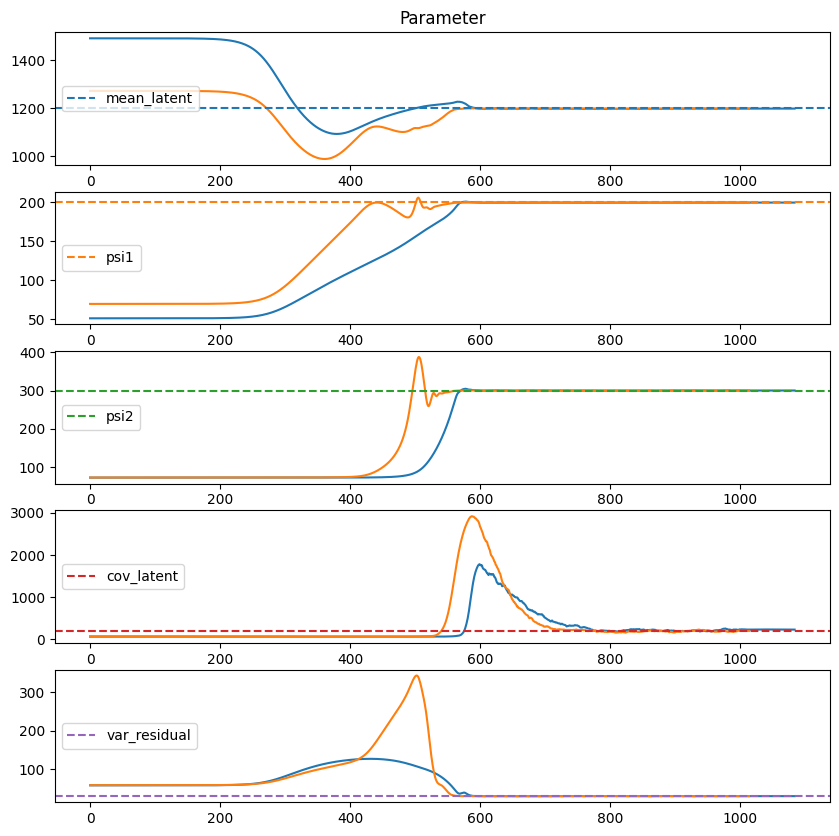

In [19]:
sdgplt.FIGSIZE = 10

fig, axs = sdgplt.plot_theta(
    res[0].final_result,
    dim_ld=myHDModel.DIM_LD,
    params_star=myHDModel.hstack_params(p_star),
    params_names=myHDModel.params_names,
)

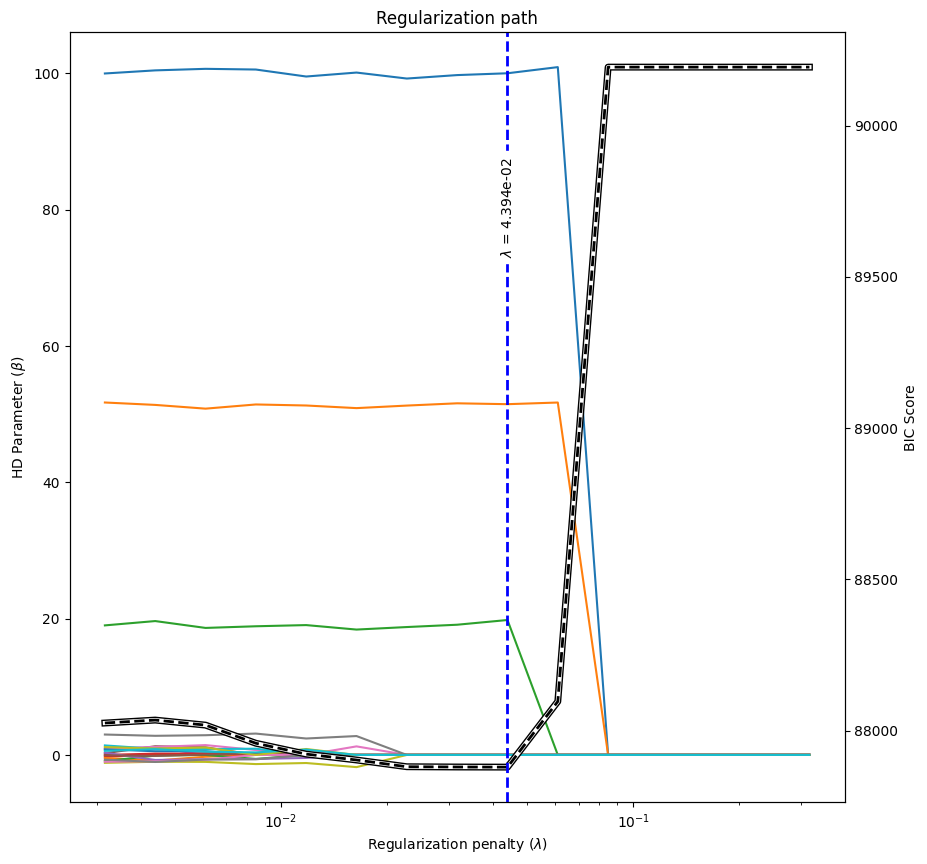

In [20]:
_ = sdgplt.plot_reg_path(res[0], myHDModel.DIM_LD)